# Performance Evaluation

In this notebook, we evaluate the effectiveness of the volatility-based trading strategy using standard portfolio performance metrics.

Objectives:
1. Measure risk-adjusted returns
2. Analyze downside risk and drawdowns
3. Compare strategy performance against benchmark returns
4. Evaluate portfolio stability and consistency

These metrics help determine whether the strategy provides meaningful improvement over passive market exposure.

# Performance Evaluation

In this notebook, we evaluate the effectiveness of the volatility-adaptive trading framework using standard portfolio performance metrics.

Objectives:
1. Measure risk-adjusted returns
2. Analyze downside risk
3. Evaluate drawdowns
4. Compare adaptive exposure against passive investing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
sp500 = pd.read_csv(
    "../data/SP500_processed.csv",
    index_col="Date",
    parse_dates=True
)

In [3]:
sp500["rolling_vol"] = (
    sp500["log_return"]
    .rolling(30)
    .std()
)

In [4]:
low_threshold = sp500["rolling_vol"].quantile(0.33)

high_threshold = sp500["rolling_vol"].quantile(0.66)

In [5]:
conditions = [
    sp500["rolling_vol"] <= low_threshold,
    
    sp500["rolling_vol"] <= high_threshold
]

choices = [
    1.0,
    0.5
]

sp500["position_size"] = np.select(
    conditions,
    choices,
    default=0.2
)

In [6]:
sp500["strategy_return"] = (
    sp500["position_size"].shift(1)
    * sp500["log_return"]
)

In [7]:
strategy_annual_return = (
    sp500["strategy_return"].mean()
    * 252
)

market_annual_return = (
    sp500["log_return"].mean()
    * 252
)

In [8]:
strategy_volatility = (
    sp500["strategy_return"].std()
    * np.sqrt(252)
)

market_volatility = (
    sp500["log_return"].std()
    * np.sqrt(252)
)

In [9]:
strategy_sharpe = (
    strategy_annual_return
    / strategy_volatility
)

market_sharpe = (
    market_annual_return
    / market_volatility
)

In [10]:
sp500["portfolio_value"] = (
    100
    * (1 + sp500["strategy_return"]).cumprod()
)

In [11]:
rolling_peak = (
    sp500["portfolio_value"]
    .cummax()
)

drawdown = (
    sp500["portfolio_value"]
    - rolling_peak
) / rolling_peak

max_drawdown = drawdown.min()

In [12]:
summary = pd.DataFrame({
    "Metric": [
        "Annual Return",
        "Annual Volatility",
        "Sharpe Ratio",
        "Maximum Drawdown"
    ],
    
    "Strategy": [
        strategy_annual_return,
        strategy_volatility,
        strategy_sharpe,
        max_drawdown
    ]
})

summary

,Metric,Strategy
0,Annual Return,0.050590
1,Annual Volatility,0.076119
2,Sharpe Ratio,0.664614
3,Maximum Drawdown,-0.113860


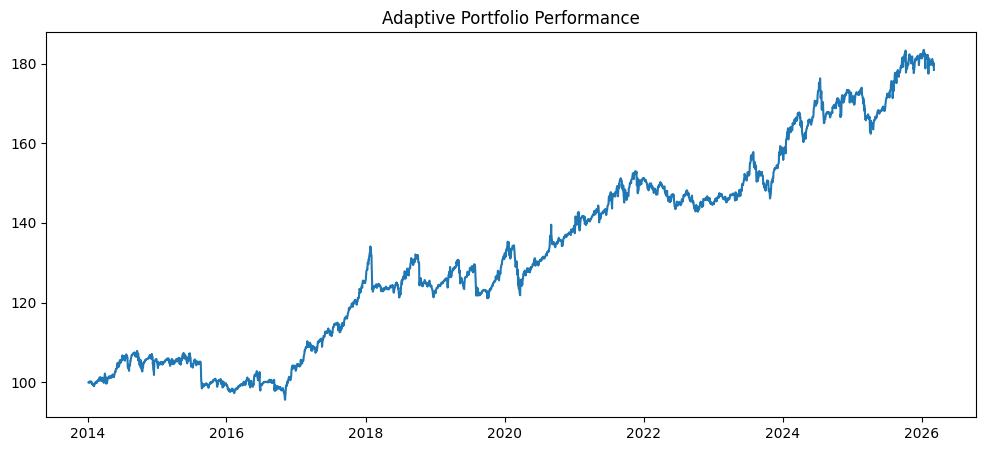

In [13]:
plt.figure(figsize=(12,5))

plt.plot(
    sp500["portfolio_value"]
)

plt.title("Adaptive Portfolio Performance")

plt.show()

## Performance Interpretation

The volatility-adaptive framework evaluates whether dynamic exposure control improves risk-adjusted performance relative to passive market participation.

Metrics such as Sharpe ratio and maximum drawdown provide insight into portfolio efficiency and downside protection.

# Overall Project Conclusion

This project developed a volatility-adaptive trading and risk management framework using ARMA-GARCH modeling.

The workflow:
1. removes weak mean structure using ARMA
2. forecasts future volatility using GARCH
3. converts volatility forecasts into market risk regimes
4. dynamically adjusts portfolio exposure based on forecasted risk
5. evaluates performance through backtesting and risk-adjusted metrics

The framework demonstrates how volatility forecasting can be integrated into adaptive trading and portfolio risk management systems.

## Performance Interpretation

The volatility-aware strategy attempts to improve risk-adjusted performance by dynamically reducing exposure during turbulent market conditions.

Performance metrics such as Sharpe ratio and maximum drawdown provide insight into whether the strategy delivers improved portfolio stability relative to passive market exposure.

# Overall Project Conclusion

This project developed a complete financial econometrics and quantitative trading workflow for volatility analysis and risk-aware portfolio management.

The study demonstrated:

1. Financial returns exhibit volatility clustering and ARCH effects
2. ARMA models capture limited mean predictability
3. GARCH models successfully model time-varying volatility
4. Volatility forecasts can inform dynamic portfolio allocation
5. Volatility-aware strategies may improve downside risk management

BTC consistently exhibited higher volatility, stronger tail risk, and more persistent high-volatility regimes relative to SP500.

The project integrates financial time series analysis, econometric modeling, volatility forecasting, risk estimation, and quantitative strategy evaluation into a unified research framework.